# Logistic Regression Project Exercise
Corresponds to the exercise in the python notebooks directory.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('../../jupyter_notebooks/DATA/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


What are the possible outcomes?

In [3]:
df['target'].unique()

array([1, 0])

Are the outcome classes' sample sets balanced?

In [4]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='count'>

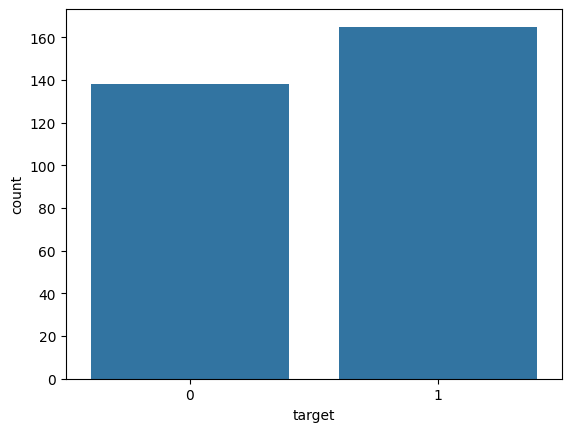

In [6]:
sns.barplot(df['target'].value_counts())

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## visualization

<Axes: xlabel='target', ylabel='count'>

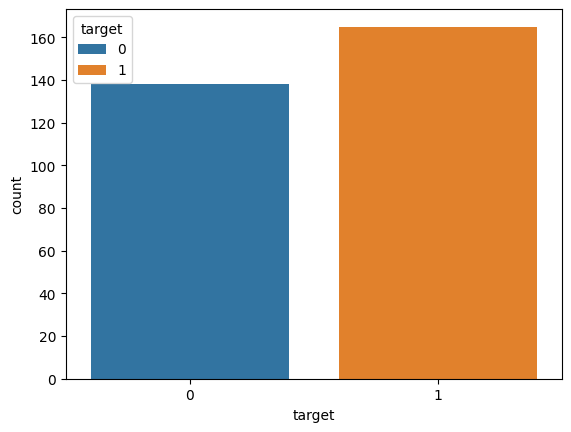

In [13]:
sns.countplot(data=df,x='target', hue='target')

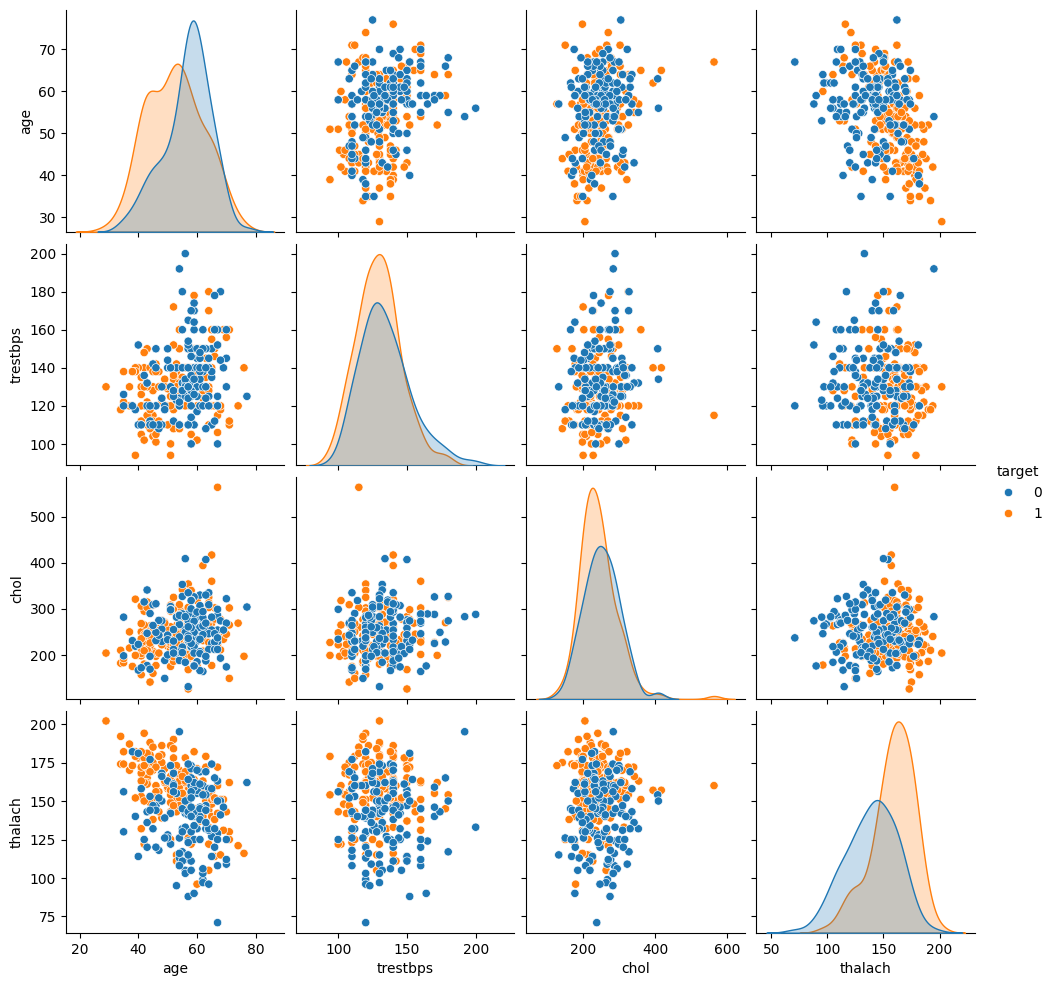

In [21]:
sns.pairplot(data=df[['age', 'trestbps', 'chol', 'thalach','target']],hue='target')

<Axes: >

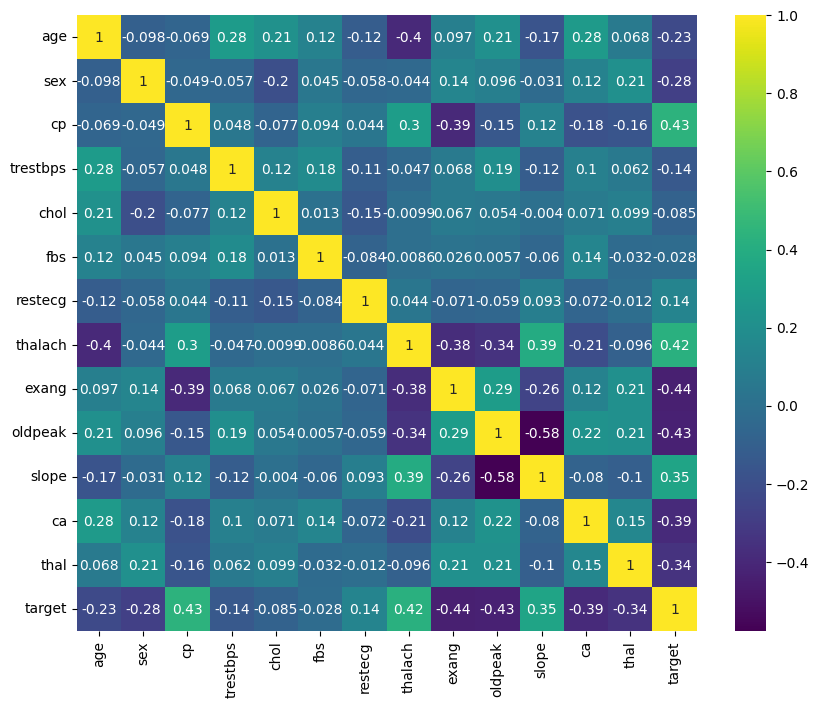

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='viridis')

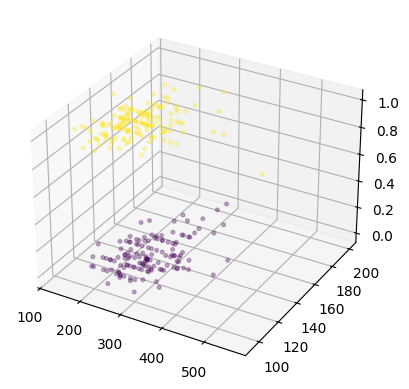

In [41]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df['chol'],df['trestbps'],df['target'],alpha=0.3,s=7,c=df['target'])

## Machine Learning

In [28]:
X = df.drop('target',axis=1)
y=df['target']

### data set split

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=101)

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [34]:
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

### Logistic Regression Model

In [55]:
from sklearn.linear_model import LogisticRegressionCV

In [56]:
log_model = LogisticRegressionCV()
log_model.fit(X_train_scaled,y_train)

,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,100
,class_weight,None
,n_jobs,None


In [109]:
log_model.Cs_

array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04])

In [57]:
log_model.C_

array([0.04641589])

In [58]:
log_model.get_params()

{'Cs': 10,
 'class_weight': None,
 'cv': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1.0,
 'l1_ratios': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'refit': True,
 'scoring': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0}

In [59]:
log_model.coef_

array([[-0.09624234, -0.39455733,  0.53541263, -0.13845013, -0.0882132 ,
         0.02495565,  0.08083019,  0.29896895, -0.33440044, -0.35252781,
         0.25100118, -0.49732614, -0.37440968]])

## Bonus task
bar-plot the coeficients

<Axes: xlabel='None'>

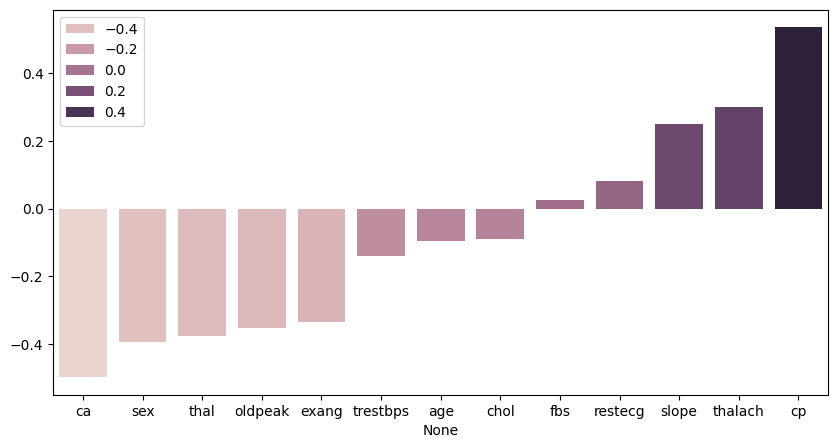

In [75]:
plt.figure(figsize=(10,5))
columns=X.columns
values = log_model.coef_[0]
dserie = pd.Series(index=columns,data=values)
dserie = dserie.sort_values()
sns.barplot(x=dserie.index,y=dserie.values,hue=dserie.values)

## Model evaluation

In [76]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [77]:
y_pred=log_model.predict(X_test_scaled)
y_pred

array([0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 0])

In [78]:
accuracy_score(y_test,y_pred)

0.8387096774193549

In [79]:
confusion_matrix(y_test,y_pred)

array([[12,  3],
       [ 2, 14]])

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

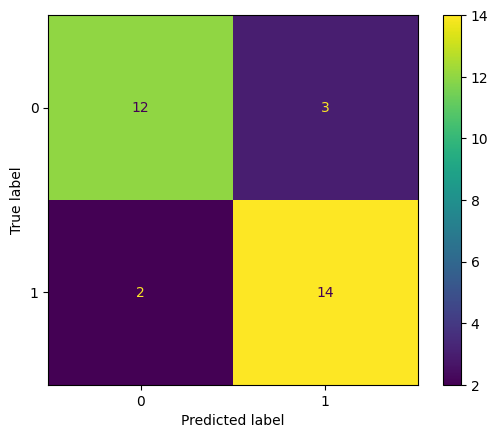

In [81]:
cm=confusion_matrix(y_test,y_pred)
cm_display=ConfusionMatrixDisplay(cm).plot()

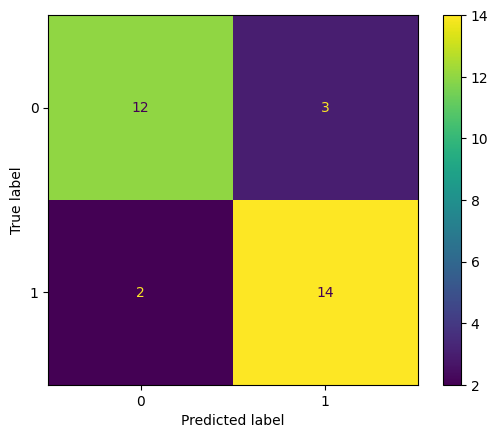

In [82]:
ConfusionMatrixDisplay.from_estimator(log_model, X_test_scaled,y_test)

In [84]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        15
           1       0.82      0.88      0.85        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



In [86]:
from sklearn.metrics import precision_score,recall_score

In [87]:
precision_score(y_test,y_pred)

0.8235294117647058

In [88]:
recall_score(y_test,y_pred)

0.875

### Performance Curves

In [89]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

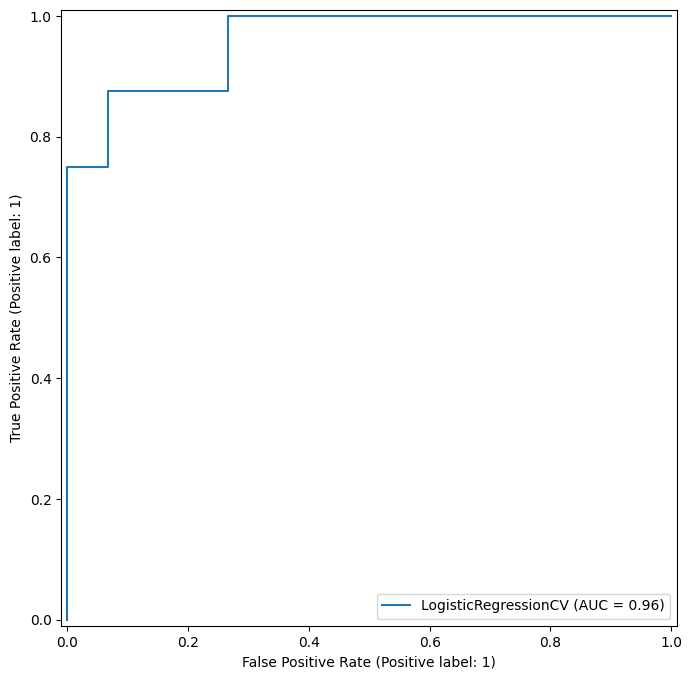

In [91]:
fig,ax = plt.subplots(figsize=(12,8),dpi=100)
RocCurveDisplay.from_estimator(log_model, X_test_scaled, y_test, ax = ax)

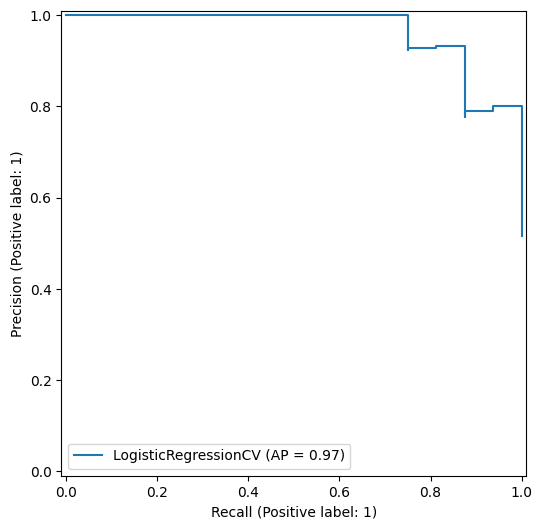

In [92]:
fig,ax=plt.subplots(figsize=(6,8),dpi=100)
PrecisionRecallDisplay.from_estimator(log_model,X_test_scaled,y_test,ax=ax)

In [96]:
patient_dict={'age':48.0,'sex':0.0,'cp':2.0,'trestbps':130.0,'chol':275.0,'fbs':0.0,
'restecg':       1.0,
'thalach':     139.0,
'exang'  :       0.0,
'oldpeak':       0.2,
'slope'  :       2.0,
'ca'     :       0.0,
'thal'   :       2.0}

In [98]:
patient=pd.DataFrame(patient_dict,index=[0])
patient

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,48.0,0.0,2.0,130.0,275.0,0.0,1.0,139.0,0.0,0.2,2.0,0.0,2.0


In [99]:
scaled_patient=scaler.transform(patient)

In [100]:
log_model.predict(scaled_patient)

array([1])

In [110]:
log_model.predict_proba(scaled_patient)

array([[0.07553013, 0.92446987]])

In [111]:
log_model.predict_proba(patient)

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegressionCV was fitted without feature names
  warnings.warn(


array([[0.99479898, 0.00520102]])

In [104]:
patient2_dict={'age':54,'sex':1,'cp':0,'trestbps':122.0,'chol':286.0,'fbs':0.0,
'restecg':       0.0,
'thalach':     116.0,
'exang'  :       1.0,
'oldpeak':       3.2,
'slope'  :       1.0,
'ca'     :       2.0,
'thal'   :       2.0}
patient2=pd.DataFrame(patient2_dict,index=[0])
patient2

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,54,1,0,122.0,286.0,0.0,0.0,116.0,1.0,3.2,1.0,2.0,2.0


In [105]:
scaled_patient2=scaler.transform(patient2)

In [106]:
log_model.predict(scaled_patient2)

array([0])

In [107]:
log_model.predict_proba(scaled_patient2)

array([[0.94751441, 0.05248559]])

In [108]:
log_model.predict_proba(patient2)

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegressionCV was fitted without feature names
  warnings.warn(


array([[9.99999860e-01, 1.39946031e-07]])